## Get the Data

Either use the provided .csv file or (optionally) get fresh (the freshest?) data from running an SQL query on StackExchange: 

Follow this link to run the query from [StackExchange](https://data.stackexchange.com/stackoverflow/query/675441/popular-programming-languages-per-over-time-eversql-com) to get your own .csv file

<code>
select dateadd(month, datediff(month, 0, q.CreationDate), 0) m, TagName, count(*)
from PostTags pt
join Posts q on q.Id=pt.PostId
join Tags t on t.Id=pt.TagId
where TagName in ('java','c','c++','python','c#','javascript','assembly','php','perl','ruby','visual basic','swift','r','object-c','scratch','go','swift','delphi')
and q.CreationDate < dateadd(month, datediff(month, 0, getdate()), 0)
group by dateadd(month, datediff(month, 0, q.CreationDate), 0), TagName
order by dateadd(month, datediff(month, 0, q.CreationDate), 0)
</code>

## Import Statements

In [118]:
import pandas as pd
import matplotlib.pyplot as plt

## Data Exploration

**Challenge**: Read the .csv file and store it in a Pandas dataframe

In [90]:
df = pd.read_csv('QueryResults.csv', names=['DATE', 'TAG', 'POSTS'], header=0)

**Challenge**: Examine the first 5 rows and the last 5 rows of the of the dataframe

In [91]:
df.head()
df.tail() 

,DATE,TAG,POSTS
1986,2020-07-01 00:00:00,r,5694
1987,2020-07-01 00:00:00,go,743
1988,2020-07-01 00:00:00,ruby,775
1989,2020-07-01 00:00:00,perl,182
1990,2020-07-01 00:00:00,swift,3607


**Challenge:** Check how many rows and how many columns there are. 
What are the dimensions of the dataframe?

In [92]:
df.columns

Index(['DATE', 'TAG', 'POSTS'], dtype='object')

**Challenge**: Count the number of entries in each column of the dataframe

In [93]:
df.count()

DATE     1991
TAG      1991
POSTS    1991
dtype: int64

**Challenge**: Calculate the total number of post per language.
Which Programming language has had the highest total number of posts of all time?

In [94]:

# SHOW ONLY TAGS COLUMN
df.groupby('TAG').sum()['POSTS']


TAG
assembly        34852
c              336042
c#            1423530
c++            684210
delphi          46212
go              47499
java          1696403
javascript    2056510
perl            65286
php           1361988
python        1496210
r              356799
ruby           214582
swift          273055
Name: POSTS, dtype: int64

Some languages are older (e.g., C) and other languages are newer (e.g., Swift). The dataset starts in September 2008.

**Challenge**: How many months of data exist per language? Which language had the fewest months with an entry? 


In [95]:
df.groupby('TAG').count()


,DATE,POSTS
TAG,,
assembly,144,144
c,144,144
c#,145,145
c++,144,144
delphi,144,144
go,129,129
java,144,144
javascript,144,144
perl,144,144


## Data Cleaning

Let's fix the date format to make it more readable. We need to use Pandas to change format from a string of "2008-07-01 00:00:00" to a datetime object with the format of "2008-07-01"

In [96]:
df['DATE'][1]

'2008-08-01 00:00:00'

In [97]:
df.DATE[1]

'2008-08-01 00:00:00'

In [98]:
type(df['DATE'][1])

str

## Data Manipulation



In [99]:

df.DATE = pd.to_datetime(df.DATE)
df.head()

,DATE,TAG,POSTS
0,2008-07-01,c#,3
1,2008-08-01,assembly,8
2,2008-08-01,javascript,162
3,2008-08-01,c,85
4,2008-08-01,python,124


**Challenge**: What are the dimensions of our new dataframe? How many rows and columns does it have? Print out the column names and print out the first 5 rows of the dataframe.

In [100]:
df.shape

(1991, 3)

In [101]:
df.columns

Index(['DATE', 'TAG', 'POSTS'], dtype='object')

In [102]:
df.head()

,DATE,TAG,POSTS
0,2008-07-01,c#,3
1,2008-08-01,assembly,8
2,2008-08-01,javascript,162
3,2008-08-01,c,85
4,2008-08-01,python,124


**Challenge**: Count the number of entries per programming language. Why might the number of entries be different? 

**Why might the number of entries be different?**

The number of entries per programming language can vary for several reasons:

1. **Language Age**: Older languages like C and Java have been around since before 2008, so they have data for the entire period. Newer languages like Swift (released in 2014) or Go (released in 2009) will have fewer entries.

2. **Language Popularity**: Some languages are more popular and widely used, resulting in more Stack Overflow posts and thus more monthly entries.

3. **Data Collection Period**: The dataset starts in September 2008, so any language that didn't exist or wasn't tracked before that date will have fewer entries.

4. **Missing Data**: Some months might be missing for certain languages due to data collection issues or very low activity.

5. **Language Lifecycle**: Some languages might have periods of decline where they have no posts for certain months.

In [103]:
# Count the number of entries (months) per programming language
entries_per_language = df.groupby('TAG').count()['DATE']  # We can use any column since count() counts non-null values

# Sort from least to most entries
entries_sorted = entries_per_language.sort_values(ascending=True)

print("Number of entries per programming language:")
print(entries_sorted)

print(f"\nLanguage with fewest entries: {entries_sorted.index[0]} ({entries_sorted.iloc[0]} months)")
print(f"Language with most entries: {entries_sorted.index[-1]} ({entries_sorted.iloc[-1]} months)")

# Calculate the date range of the dataset
print(f"\nDataset date range:")
print(f"From: {df['DATE'].min()}")
print(f"To: {df['DATE'].max()}")
print(f"Total possible months: {(df['DATE'].max().year - df['DATE'].min().year) * 12 + (df['DATE'].max().month - df['DATE'].min().month) + 1}")

Number of entries per programming language:
TAG
go            129
swift         135
r             142
assembly      144
java          144
delphi        144
c++           144
c             144
python        144
javascript    144
php           144
perl          144
ruby          144
c#            145
Name: DATE, dtype: int64

Language with fewest entries: go (129 months)
Language with most entries: c# (145 months)

Dataset date range:
From: 2008-07-01 00:00:00
To: 2020-07-01 00:00:00
Total possible months: 145


In [114]:
reshaped_df = df.pivot(index='DATE', columns='TAG', values='POSTS').fillna(0)

In [115]:
reshaped_df

TAG,assembly,c,c#,c++,delphi,go,java,javascript,perl,php,python,r,ruby,swift
DATE,,,,,,,,,,,,,,
2008-07-01,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2008-08-01,8.0,85.0,511.0,164.0,14.0,0.0,222.0,162.0,28.0,161.0,124.0,0.0,73.0,0.0
2008-09-01,28.0,321.0,1649.0,755.0,105.0,0.0,1137.0,640.0,131.0,482.0,542.0,6.0,290.0,0.0
2008-10-01,15.0,303.0,1989.0,811.0,112.0,0.0,1153.0,725.0,127.0,617.0,510.0,0.0,249.0,0.0
2008-11-01,17.0,259.0,1730.0,735.0,141.0,0.0,958.0,579.0,97.0,504.0,452.0,1.0,160.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-01,317.0,2670.0,8954.0,5107.0,181.0,719.0,13253.0,20483.0,215.0,6672.0,26673.0,5761.0,780.0,3434.0
2020-04-01,406.0,3472.0,10042.0,6820.0,250.0,887.0,15377.0,24634.0,240.0,8060.0,32605.0,7047.0,860.0,4015.0
2020-05-01,386.0,3602.0,9923.0,7063.0,221.0,826.0,14711.0,25196.0,228.0,7917.0,34478.0,6833.0,774.0,4066.0


## Data Visualisaton with with Matplotlib


**Challenge**: Use the [matplotlib documentation](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.plot.html#matplotlib.pyplot.plot) to plot a single programming language (e.g., java) on a chart.

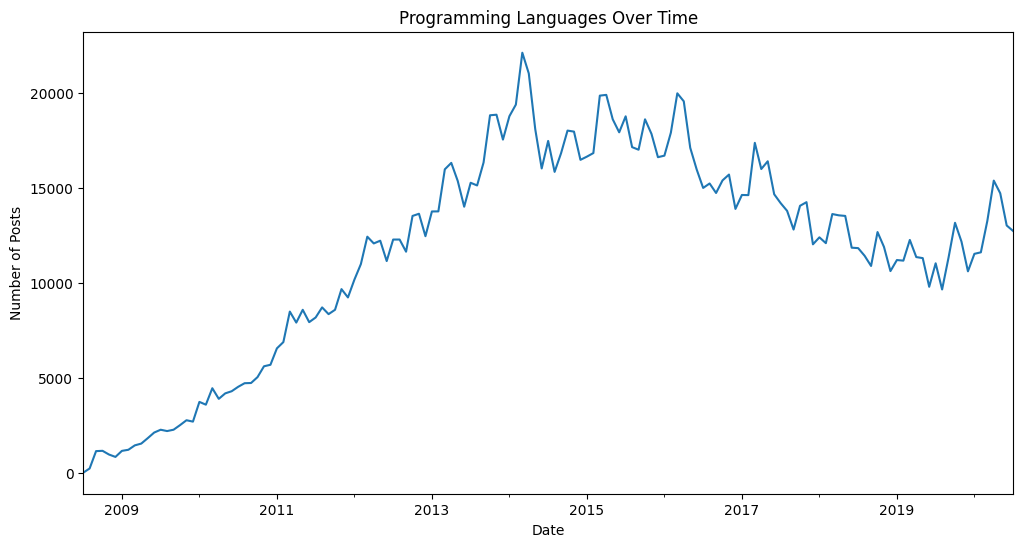

In [135]:
plot = reshaped_df.java.plot(figsize=(12, 6), title='Programming Languages Over Time', ylabel='Number of Posts', xlabel='Date')


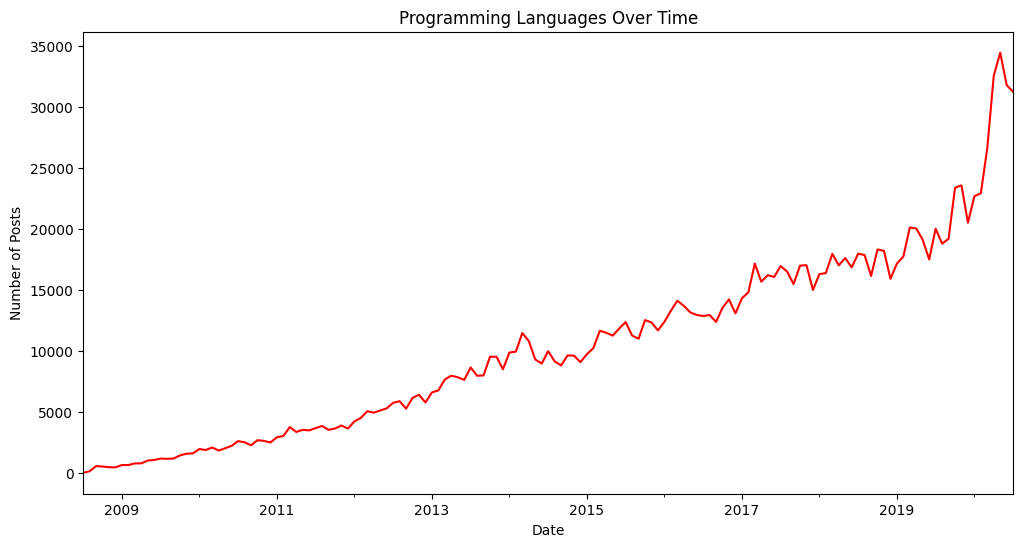

In [137]:
plot = reshaped_df.python.plot(figsize=(12, 6), title='Programming Languages Over Time', ylabel='Number of Posts', xlabel='Date', color ='red')

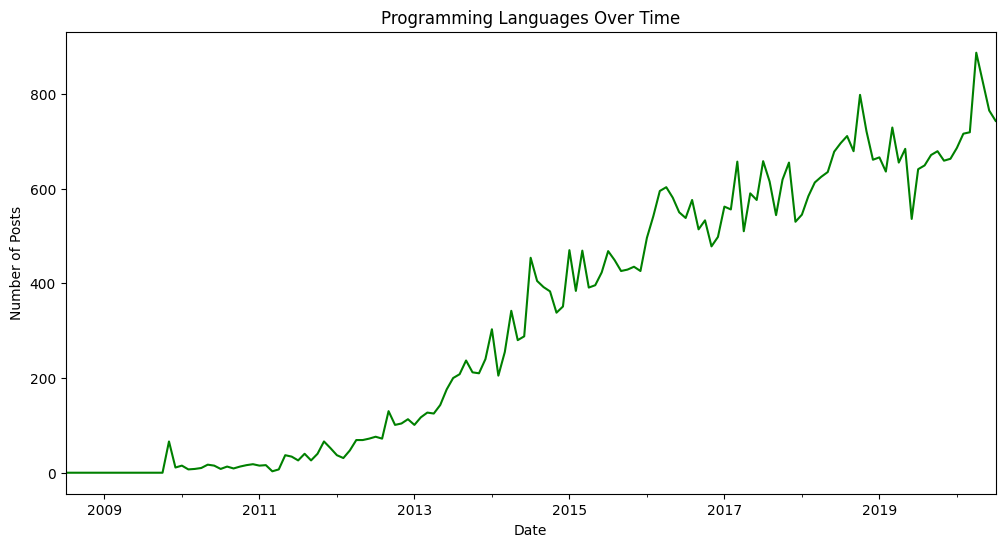

In [136]:
plot = reshaped_df.go.plot(figsize=(12, 6), title='Programming Languages Over Time', ylabel='Number of Posts', xlabel='Date', color='green')


**Challenge**: Show two line (e.g. for Java and Python) on the same chart.

# Smoothing out Time Series Data

Time series data can be quite noisy, with a lot of up and down spikes. To better see a trend we can plot an average of, say 6 or 12 observations. This is called the rolling mean. We calculate the average in a window of time and move it forward by one overservation. Pandas has two handy methods already built in to work this out: [rolling()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.rolling.html) and [mean()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.core.window.rolling.Rolling.mean.html). 